<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Lung%20Cancer%20Detection%20using%20Convolutional%20Neural%20Network%20(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn import metrics

import tensorflow as tf
from tensorflow import keras
from keras import layers

import warnings
warnings.filterwarnings('ignore')

In [4]:
from zipfile import ZipFile

# import the dataset
data_path = '/content/lung_subset_small.zip'
with ZipFile(data_path,'r') as zip:
  zip.extractall()
  print('The data set has been extracted.')

The data set has been extracted.


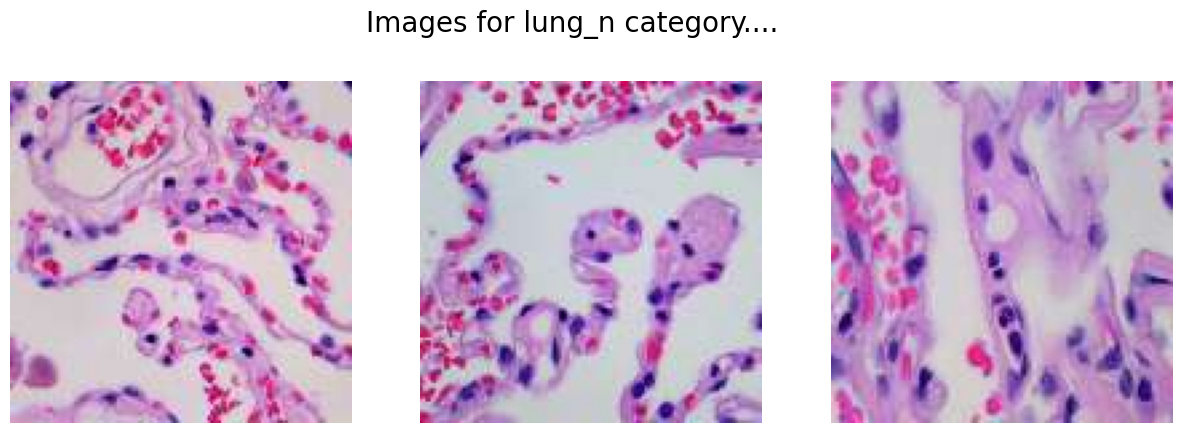

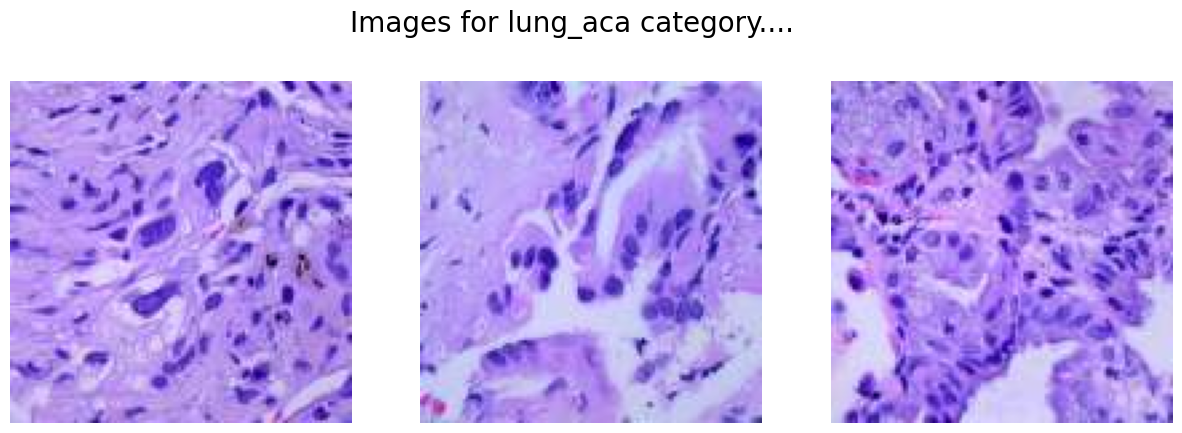

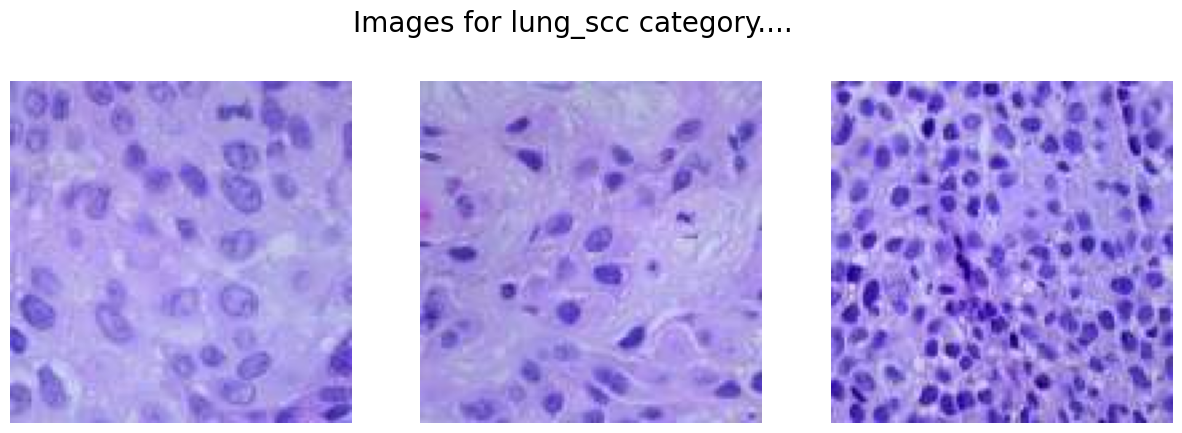

In [5]:
# Visualizing the data
path = 'lung_subset_small'

classes = ['lung_n','lung_aca','lung_scc']

for cat in classes:
  image_dir = f'{path}/{cat}'
  images = os.listdir(image_dir)

  fig,ax = plt.subplots(1,3,figsize=(15,5))
  fig.suptitle(f'Images for {cat} category....',fontsize=20)

  for i in range(3):
    k = np.random.randint(0,len(images))
    img = np.array(Image.open(f'{path}/{cat}/{images[k]}'))
    ax[i].imshow(img)
    ax[i].axis('off')

  plt.show()


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Preparing the dataset
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 10

datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

train_data = datagen.flow_from_directory(path,target_size=(IMG_SIZE,IMG_SIZE),batch_size=BATCH_SIZE,class_mode='categorical',subset='training')

val_data = datagen.flow_from_directory(path,target_size=(IMG_SIZE,IMG_SIZE),batch_size=BATCH_SIZE,class_mode='categorical',subset='validation')

Found 1920 images belonging to 3 classes.
Found 480 images belonging to 3 classes.


In [11]:
# Model Development
model = keras.models.Sequential([layers.Conv2D(32,(5,5),activation='relu',padding='same',input_shape=(IMG_SIZE,IMG_SIZE,3)),layers.MaxPooling2D(2,2),
                                 layers.Conv2D(64,(3,3),activation='relu',padding='same'),layers.MaxPooling2D(2,2),
                                 layers.Conv2D(128,(3,3),activation='relu',padding='same'),layers.MaxPooling2D(2,2),

                                 layers.Flatten(),
                                 layers.Dense(256,activation='relu'),
                                 layers.BatchNormalization(),
                                 layers.Dense(128,activation='relu'),
                                 layers.Dropout(0.3),
                                 layers.BatchNormalization(),
                                 layers.Dense(3,activation='softmax')
                                 ])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,518,467 (32.50 MB)

 Trainable params: 8,517,699 (32.49 MB)

 Non-trainable params: 768 (3.00 KB)

In [12]:
#Model Compilation
from keras.callbacks import EarlyStopping,ReduceLROnPlateau

class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs=None):
    if logs.get('val_accuracy')>0.90:
      print("Stopping early")
      self.model.stop_training = True

es = EarlyStopping(patience=3,monitor='val_accuracy',restore_best_weights=True)

lr = ReduceLROnPlateau(monitor='val_loss',patience=2,factor=0.5)

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [13]:
#Model Training
history = model.fit(train_data,validation_data=val_data,epochs=EPOCHS,callbacks=[es,lr,myCallback()])

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 107s 863ms/step - accuracy: 0.7917 - loss: 0.5294 - val_accuracy: 0.6104 - val_loss: 2.3188 - learning_rate: 0.0010
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 94s 782ms/step - accuracy: 0.8286 - loss: 0.4422 - val_accuracy: 0.5771 - val_loss: 4.6114 - learning_rate: 0.0010
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 91s 761ms/step - accuracy: 0.8604 - loss: 0.3605 - val_accuracy: 0.3396 - val_loss: 12.1819 - learning_rate: 0.0010
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 90s 747ms/step - accuracy: 0.8958 - loss: 0.2760 - val_accuracy: 0.3708 - val_loss: 7.1490 - learning_rate: 5.0000e-04


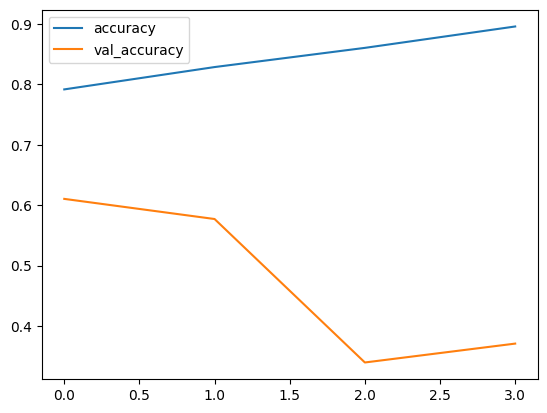

In [15]:
import pandas as pd

#Visualizing
history_df = pd.DataFrame(history.history)
history_df.loc[:,['accuracy','val_accuracy']].plot()
plt.show()

In [17]:
# Model Evaluation
Y_pred = model.predict(val_data)
Y_pred_labels = np.argmax(Y_pred,axis=1)
Y_true = val_data.classes
from sklearn import metrics

print(metrics.classification_report(Y_true,Y_pred_labels,target_names=classes))

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step
              precision    recall  f1-score   support

      lung_n       0.34      0.74      0.47       160
    lung_aca       0.40      0.33      0.36       160
    lung_scc       0.00      0.00      0.00       160

    accuracy                           0.36       480
   macro avg       0.25      0.36      0.28       480
weighted avg       0.25      0.36      0.28       480

